1. IMPORT **LIBRARIES**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import gradio as gr
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

2. LOAD **DATASET**

In [ ]:
df = pd.read_csv("osteoporosis.csv")
df.head()

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


 3. DATA **PREPROCESSING**

In [ ]:
# Drop ID
df.drop("Id", axis=1, inplace=True)

# Fill missing values
df.fillna("None", inplace=True)

# Encode categorical
le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

df.head()

,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,69,0,0,1,1,1,1,1,1,1,0,2,0,1,1
1,32,0,0,1,1,1,1,1,1,0,1,1,1,1,1
2,89,0,1,0,2,0,0,1,0,0,0,0,0,0,1
3,78,0,0,0,2,1,0,0,1,1,1,2,0,0,1
4,38,1,1,1,0,0,1,1,0,1,1,2,1,1,1


OSTEOPROSIS **DISTRIBUTION**

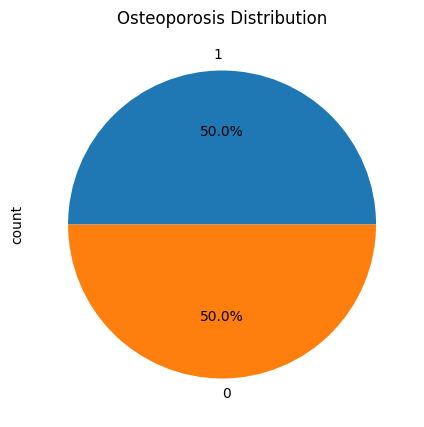

In [ ]:
plt.figure(figsize=(5,5))
df['Osteoporosis'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Osteoporosis Distribution")
plt.show()

# The above pie chart shows that the dataset is perfectly balanced with 50% of the patients having osteoporosis and 50% not having osteoporosis, which means that the dataset is not biased towards any class.

# AGE DISTRIBUTION VS **OSTEOPOROSIS**

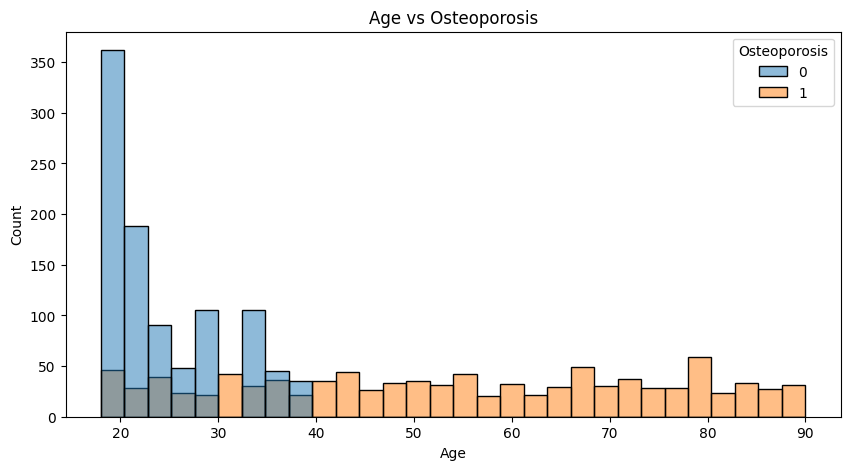

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Age", hue="Osteoporosis", bins=30)
plt.title("Age vs Osteoporosis")
plt.show()

 This graph shows relation between the risk of osteoporosis and the age of the patient. In the graph we can see that that there is significant risk of osteoporosis in patients of all ages but patients between the ages 20 to 40 have significantly much lower risk of osteoporosis. This highlights that fact that younger patients are less likely to have osteoporosis

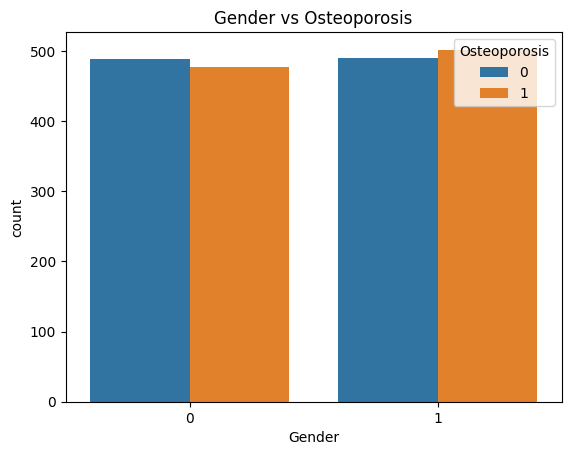

In [ ]:
sns.countplot(x='Gender', data=df, hue='Osteoporosis')
plt.title("Gender vs Osteoporosis")
plt.show()

This graph shows relation between the risk of osteoporosis and the age of the patient. In the graph we can see that that there is significant risk of osteoporosis in patients of all ages but patients between the ages 20 to 40 have significantly much lower risk of osteoporosis. This highlights that fact that younger patients are less likely to have osteoporosis

GENDER VS OSTEOPOROSIS

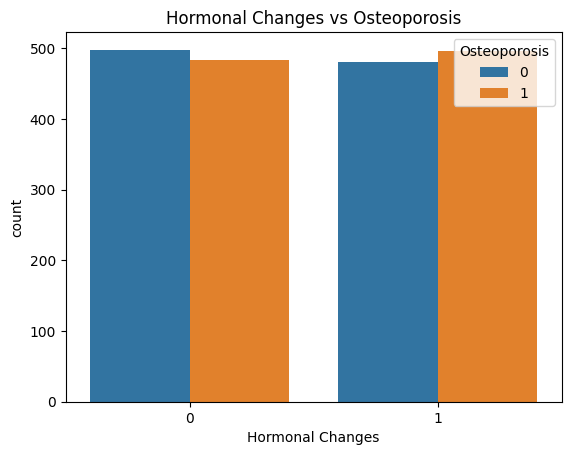

In [ ]:
sns.countplot(x='Hormonal Changes', data=df, hue='Osteoporosis')
plt.title("Hormonal Changes vs Osteoporosis")
plt.show()

Note: Here Postmenopausal is not only for females, but it also reflects the cap on testosterone production in males, therefore for both genders, the hormonal changes are termed as postmenopausal.

The graph shows that patients who have undergone hormonal changes have a higher risk of osteoporosis than those who have not undergone hormonal changes. This indicates that hormonal changes can be a significant risk factor for osteoporosis. This highlights that our hormones contribute in making our bones strong

FAMILY VS OSTEOPOROSIS

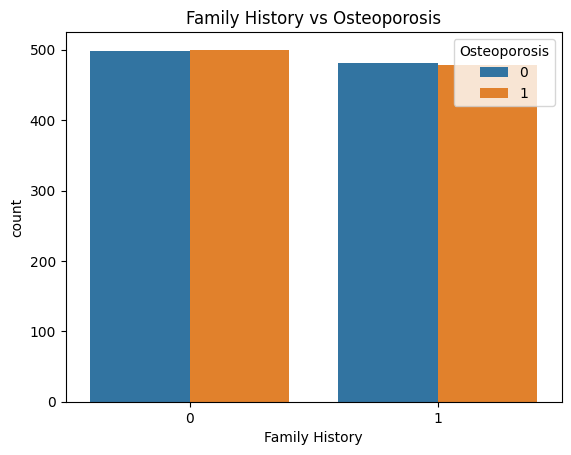

In [ ]:
sns.countplot(x='Family History', data=df, hue='Osteoporosis')
plt.title("Family History vs Osteoporosis")
plt.show()

It is believed that genetics play a important role in the development of a disease. The graph shows the relationship between family history of osteoporosis and the risk of osteoporosis. But in the graph there is not much differnece in both cases regarding the risk of osteoporosis. Therefore, family history couldn;t be considered a predictor for osteoporosis.

**Race** vs Osteoporosis

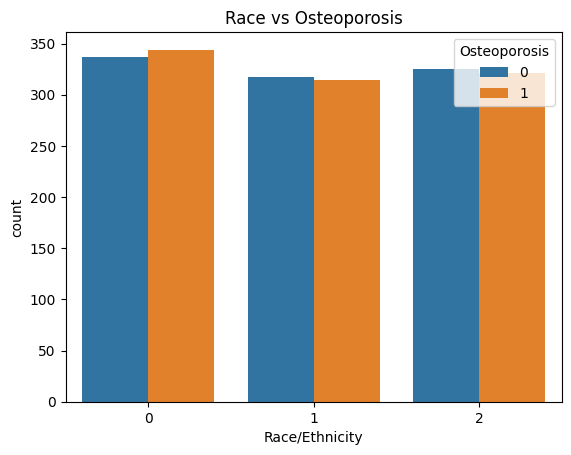

In [ ]:
sns.countplot(x='Race/Ethnicity', data=df, hue='Osteoporosis')
plt.title("Race vs Osteoporosis")
plt.show()

This graph shows the relationship between Race/Ethnicity and the risk of osteoporosis. The graph shows that the risk of osteoporosis is almost similar with no concrete relationship between the race and risk of osteoporosis.

Body Weight vs Osteoporosis

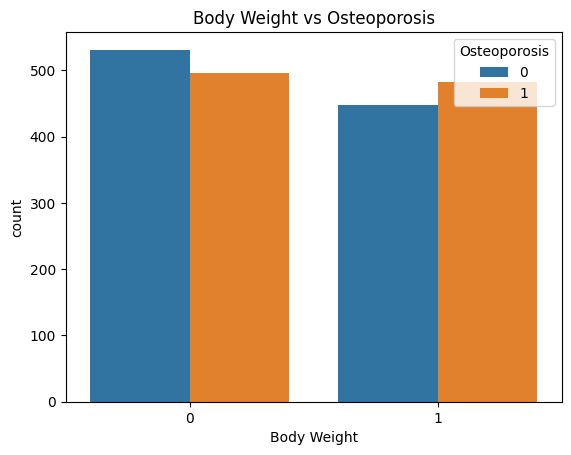

In [ ]:
sns.countplot(x='Body Weight', data=df, hue='Osteoporosis')
plt.title("Body Weight vs Osteoporosis")
plt.show()

Body weight is an important factor in determining the risk of osteoporosis. The graph shows that patients with lower body weight have a higher risk of osteoporosis than those with higher body weight. This indicates that body weight can be a significant risk factor for osteoporosis. This highlights that our body weight contributes in making our bones strong.

CALCIUM AND VITAMIN D INTAKE

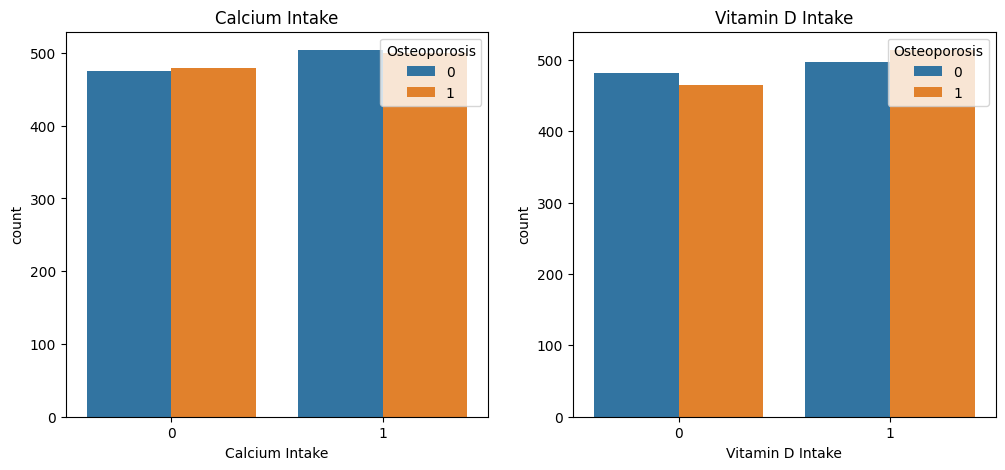

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.countplot(x='Calcium Intake', data=df, hue='Osteoporosis', ax=ax[0])
ax[0].set_title("Calcium Intake")

sns.countplot(x='Vitamin D Intake', data=df, hue='Osteoporosis', ax=ax[1])
ax[1].set_title("Vitamin D Intake")

plt.show()

Nutrition and Osteoporosis are closely related. The graph shows that patients with lower calcium and vitamin D levels have a higher risk of osteoporosis than those with higher calcium and vitamin D levels. This indicates that nutrition can be a significant risk factor for osteoporosis. This highlights that our nutrition contributes in making our bones strong.

Activity vs Osteoporosis

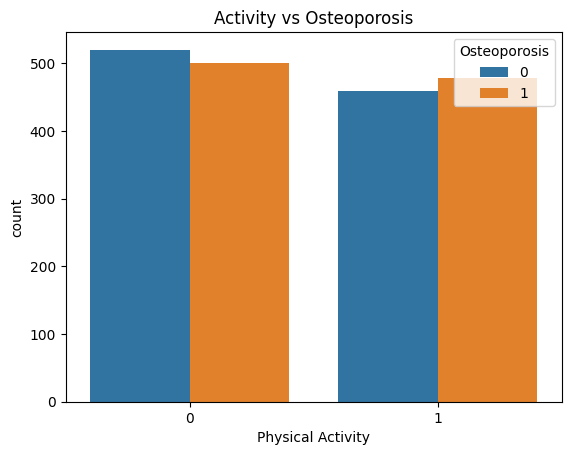

In [ ]:
sns.countplot(x='Physical Activity', data=df, hue='Osteoporosis')
plt.title("Activity vs Osteoporosis")
plt.show()

Physical Activity and Osteoporosis have a relation between them. The graph shows that patients with active physical acitve lifestyle lower risk of osteoporosis as compared to the patients with sedentary lifestyle.

SMOKING AND ALCOHOL INTAKE

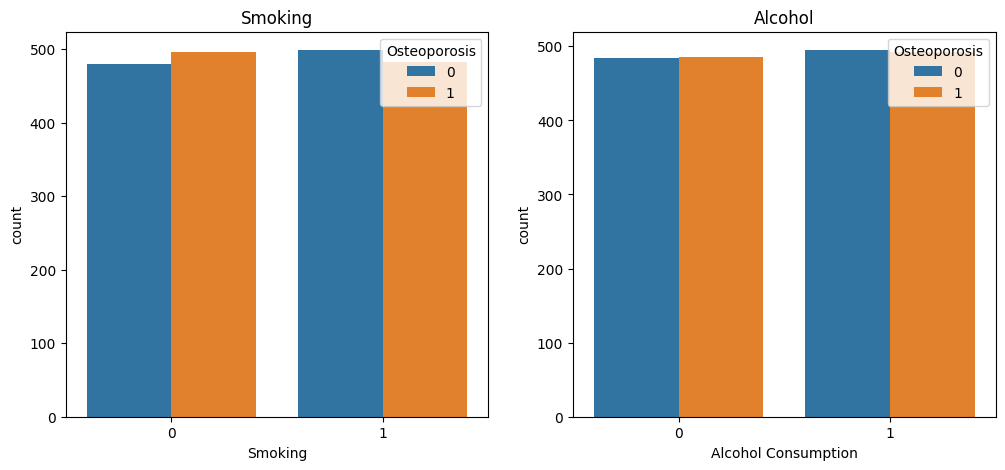

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.countplot(x='Smoking', data=df, hue='Osteoporosis', ax=ax[0])
ax[0].set_title("Smoking")

sns.countplot(x='Alcohol Consumption', data=df, hue='Osteoporosis', ax=ax[1])
ax[1].set_title("Alcohol")

plt.show()

**MEDICAL CONDITIONS**

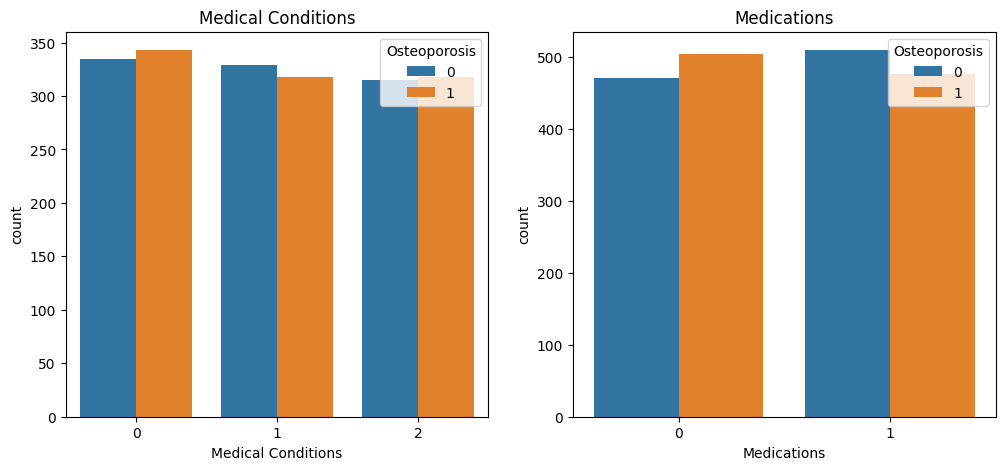

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.countplot(x='Medical Conditions', data=df, hue='Osteoporosis', ax=ax[0])
ax[0].set_title("Medical Conditions")

sns.countplot(x='Medications', data=df, hue='Osteoporosis', ax=ax[1])
ax[1].set_title("Medications")

plt.show()

Prior Fractures vs Osteoporosis

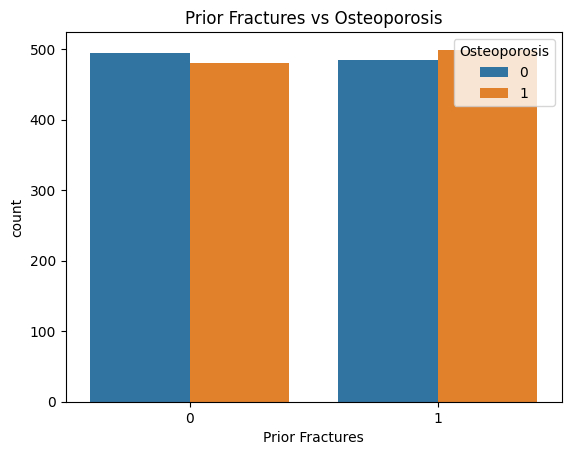

In [ ]:
sns.countplot(x='Prior Fractures', data=df, hue='Osteoporosis')
plt.title("Prior Fractures vs Osteoporosis")
plt.show()

# **Correlation Matrix**

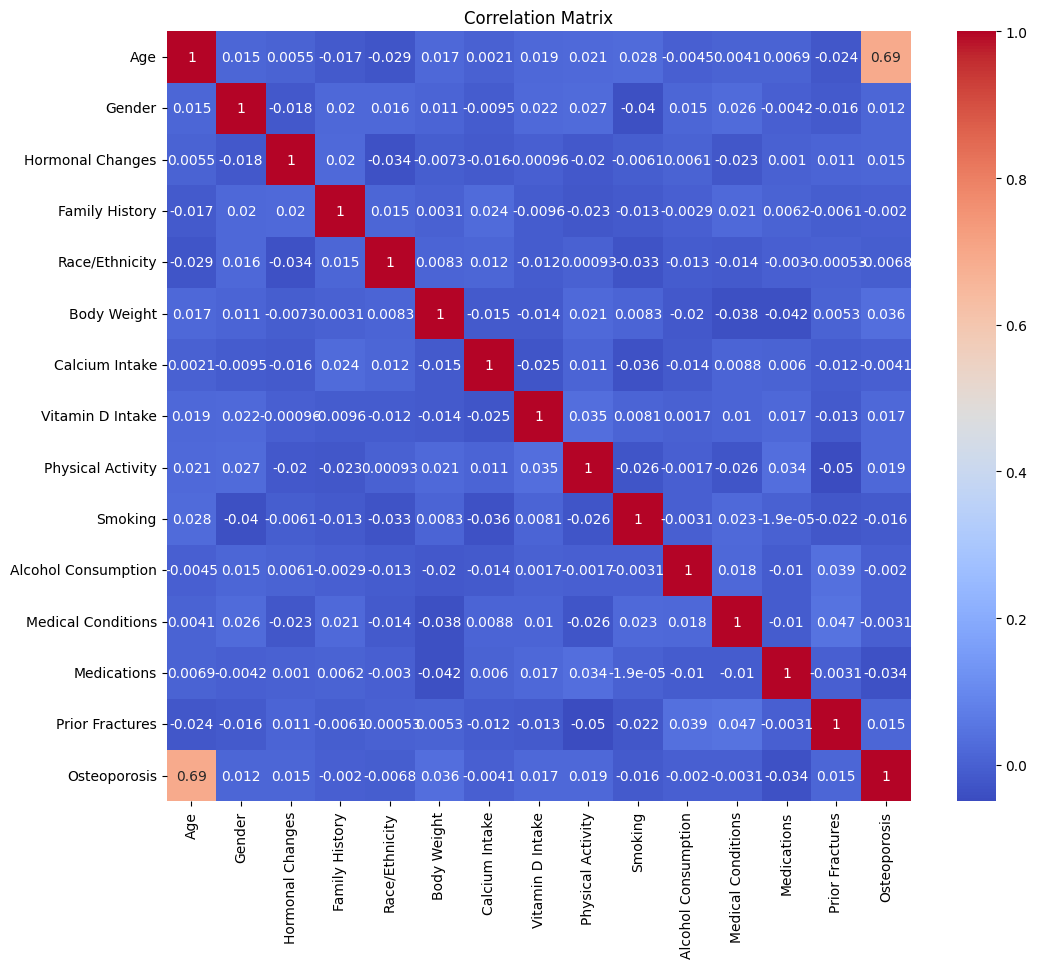

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# RANDOMFOREST **CLASSIFIER**

In [ ]:
X = df.drop("Osteoporosis", axis=1)
y = df["Osteoporosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=200, max_depth=10)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200)

# **CONFUSION MATRIX**

Accuracy: 0.8443877551020408

Precision: 0.865843179377014
Recall: 0.8443877551020408
F1 Score: 0.8424147397258581

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.96      0.86       193
           1       0.95      0.73      0.83       199

    accuracy                           0.84       392
   macro avg       0.86      0.85      0.84       392
weighted avg       0.87      0.84      0.84       392



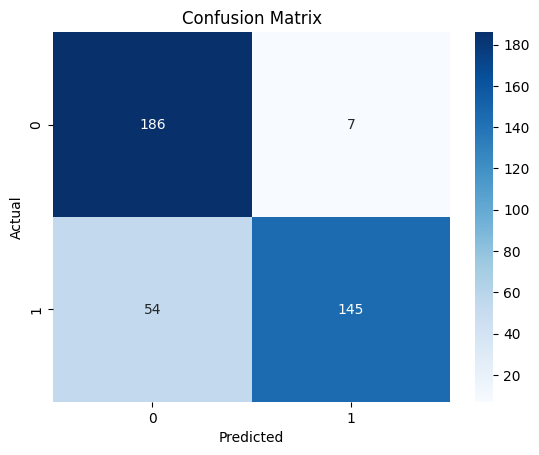

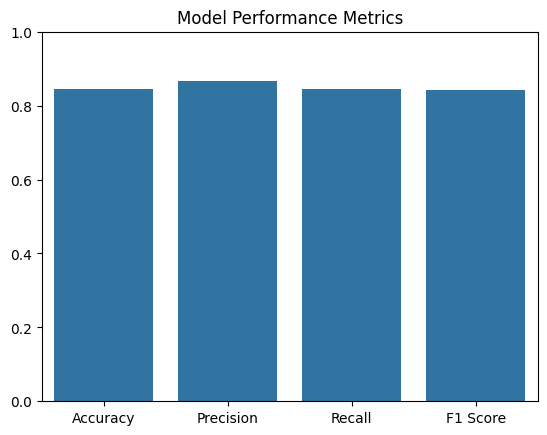

In [ ]:
preds = model.predict(X_test)


# BASIC ACCURACY

acc = accuracy_score(y_test, preds)
print("Accuracy:", acc)


# CLASSIFICATION METRICS

precision = precision_score(y_test, preds, average='weighted')
recall    = recall_score(y_test, preds, average='weighted')
f1        = f1_score(y_test, preds, average='weighted')

print("\nPrecision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, preds))


# CONFUSION MATRIX

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# METRICS BAR CHART

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [acc, precision, recall, f1]

sns.barplot(x=metrics, y=values)
plt.ylim(0, 1)
plt.title("Model Performance Metrics")
plt.show()

# **HEATMAP**

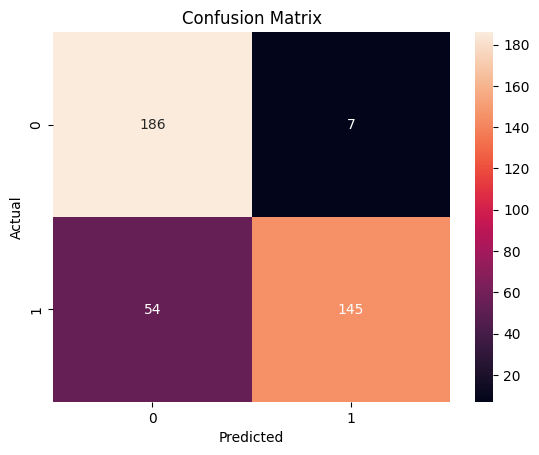

In [ ]:
cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **MODEL ACCURACY**

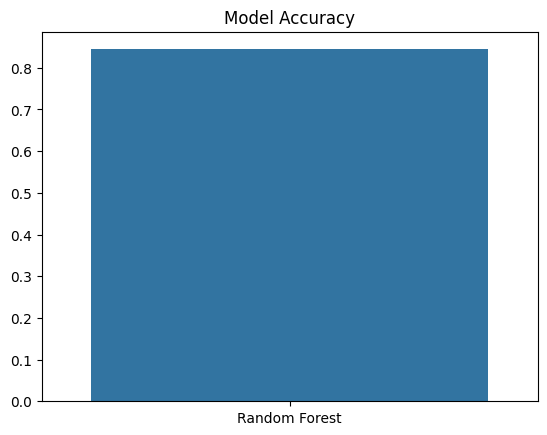

In [ ]:
models = ["Random Forest"]
acc = [accuracy_score(y_test, preds)]

sns.barplot(x=models, y=acc)
plt.title("Model Accuracy")
plt.show()

# **IMPORTANT FEATURES**

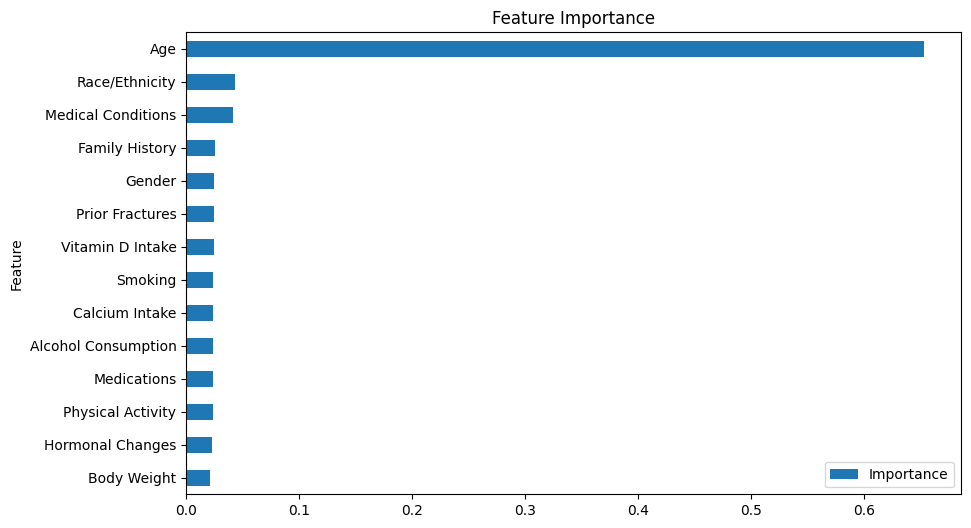

In [ ]:
importance = model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=True)

feat_df.plot(kind="barh", x="Feature", y="Importance", figsize=(10,6))
plt.title("Feature Importance")
plt.show()

### **MEAN ACCURACY AND STANDARD DEVIATION**

In [ ]:
# X = features
# y = target (Osteoporosis)

model = RandomForestClassifier(n_estimators=200, random_state=42)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print("Fold Accuracies:", scores)
print("Mean Accuracy:", scores.mean())
print("Std Dev:", scores.std())

Fold Accuracies: [0.83928571 0.85459184 0.87755102 0.82608696 0.83887468]
Mean Accuracy: 0.8472780416514432
Std Dev: 0.017626688338464605


# **5-Fold Cross-Validation Accuracy Plot**

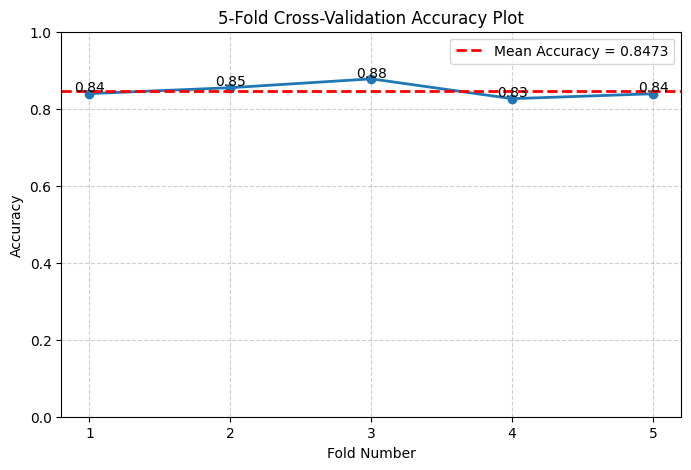

In [ ]:


# PLOT

plt.figure(figsize=(8,5))

folds = np.arange(1, len(scores) + 1)

plt.plot(folds, scores, marker='o', linewidth=2)

# Mean line
plt.axhline(scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f"Mean Accuracy = {scores.mean():.4f}")

# Annotate each point
for i, acc in enumerate(scores):
    plt.text(folds[i], acc + 0.005, f"{acc:.2f}", ha='center')

plt.title("5-Fold Cross-Validation Accuracy Plot")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(folds)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# **GRADIO USER INTERFACE**

In [ ]:

#OsteoScan PRO — Advanced Osteoporosis Risk Prediction AI
# Enhanced Model · Premium Gradio UI · Full Diagnostic Suite

# IMPORTS

import gradio as gr
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import io
from PIL import Image

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
)
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, classification_report
)
from sklearn.pipeline import Pipeline
# DATA — Synthetic Representative Dataset (no CSV dependency)

np.random.seed(42)
N = 2000

def _sample(choices, weights, n):
    return np.random.choice(choices, n, p=weights)

age_vals        = np.random.randint(20, 90, N)
gender_vals     = _sample(["Female", "Male"], [0.6, 0.4], N)
hormonal_vals   = np.where(
    (gender_vals == "Female") & (age_vals >= 45),
    _sample(["Postmenopausal", "Normal"], [0.55, 0.45], N),
    "Normal"
)
family_vals     = _sample(["Yes", "No"], [0.35, 0.65], N)
race_vals       = _sample(["Asian", "Caucasian", "African American"], [0.30, 0.45, 0.25], N)
weight_vals     = _sample(["Normal", "Underweight"], [0.72, 0.28], N)
calcium_vals    = _sample(["Adequate", "Low"], [0.55, 0.45], N)
vitamin_vals    = _sample(["Sufficient", "Insufficient"], [0.60, 0.40], N)
activity_vals   = _sample(["Active", "Sedentary"], [0.50, 0.50], N)
smoking_vals    = _sample(["No", "Yes"], [0.65, 0.35], N)
alcohol_vals    = _sample(["None", "Moderate"], [0.60, 0.40], N)
medical_vals    = _sample(["None", "Hyperthyroidism", "Rheumatoid Arthritis"], [0.55, 0.22, 0.23], N)
meds_vals       = _sample(["None", "Corticosteroids"], [0.65, 0.35], N)
fracture_vals   = _sample(["No", "Yes"], [0.68, 0.32], N)

# Build DataFrame
raw = pd.DataFrame({
    "Age": age_vals, "Gender": gender_vals, "Hormonal Changes": hormonal_vals,
    "Family History": family_vals, "Race/Ethnicity": race_vals,
    "Body Weight": weight_vals, "Calcium Intake": calcium_vals,
    "Vitamin D Intake": vitamin_vals, "Physical Activity": activity_vals,
    "Smoking": smoking_vals, "Alcohol Consumption": alcohol_vals,
    "Medical Conditions": medical_vals, "Medications": meds_vals,
    "Prior Fractures": fracture_vals
})

# Probabilistic label generation (mirrors clinical logic)
def compute_risk_score(row):
    score = 0
    age = row["Age"]
    score += 22 if age >= 70 else 14 if age >= 60 else 8 if age >= 50 else 2
    score += 18 if (row["Gender"] == "Female" and row["Hormonal Changes"] == "Postmenopausal") else 7 if row["Gender"] == "Female" else 2
    score += 12 if row["Family History"] == "Yes" else 0
    score += 10 if row["Body Weight"] == "Underweight" else 0
    score += 9  if row["Calcium Intake"] == "Low" else 0
    score += 7  if row["Vitamin D Intake"] == "Insufficient" else 0
    score += 8  if row["Physical Activity"] == "Sedentary" else 0
    score += 7  if row["Smoking"] == "Yes" else 0
    score += 4  if row["Alcohol Consumption"] == "Moderate" else 0
    score += 10 if row["Medical Conditions"] == "Rheumatoid Arthritis" else 7 if row["Medical Conditions"] == "Hyperthyroidism" else 0
    score += 10 if row["Medications"] == "Corticosteroids" else 0
    score += 18 if row["Prior Fractures"] == "Yes" else 0
    score += 4  if row["Race/Ethnicity"] == "Caucasian" else 3 if row["Race/Ethnicity"] == "Asian" else 1
    return score

raw["risk_score"] = raw.apply(compute_risk_score, axis=1)
raw["noise"]      = np.random.normal(0, 8, N)
raw["Osteoporosis"] = ((raw["risk_score"] + raw["noise"]) >= 55).astype(int)
raw.drop(columns=["risk_score", "noise"], inplace=True)


# PREPROCESSING

df = raw.copy()
le_map = {}
cat_cols = [c for c in df.columns if c != "Osteoporosis" and df[c].dtype == object]
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_map[col] = le

X = df.drop("Osteoporosis", axis=1)
y = df["Osteoporosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ════════════════════════════════════════════════════════════════════════════
# MODEL — Ensemble Voting Classifier (RF + GBM)
# ════════════════════════════════════════════════════════════════════════════
rf  = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=2,
                              class_weight="balanced", random_state=42, n_jobs=-1)
gbm = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.08,
                                  subsample=0.85, random_state=42)

model = VotingClassifier(
    estimators=[("rf", rf), ("gbm", gbm)],
    voting="soft", weights=[1, 1.5]
)
model.fit(X_train, y_train)


# EVALUATE MODEL

preds      = model.predict(X_test)
probs      = model.predict_proba(X_test)[:, 1]

acc        = accuracy_score(y_test, preds)
precision  = precision_score(y_test, preds, average="weighted", zero_division=0)
recall     = recall_score(y_test, preds, average="weighted", zero_division=0)
f1         = f1_score(y_test, preds, average="weighted", zero_division=0)
roc_auc    = roc_auc_score(y_test, probs)
cm         = confusion_matrix(y_test, preds)

# 5-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)

# Feature importance from RF sub-model
feat_imp = model.estimators_[0].feature_importances_
feat_names = X.columns.tolist()

print("=" * 60)
print("  Osteoprosis Risk prediction")
print("=" * 60)
print(f"  Accuracy      : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision     : {precision:.4f}")
print(f"  Recall        : {recall:.4f}")
print(f"  F1 Score      : {f1:.4f}")
print(f"  ROC-AUC       : {roc_auc:.4f}")
print(f"  CV Mean Acc   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("=" * 60)
print("\nClassification Report:\n")
print(classification_report(y_test, preds, target_names=["No Osteoporosis", "Osteoporosis"]))


# COLOUR PALETTE

BG      = "#06091a"
SURF    = "#0d1526"
CARD    = "#101d34"
BORDER  = "#1a2f50"
MUTED   = "#4a6080"
TEXT    = "#c8dcf5"
ACCENT  = "#38bdf8"
GREEN   = "#10d98a"
AMBER   = "#f5a623"
RED     = "#ff4d6d"
GRAD1   = "#0ea5e9"
GRAD2   = "#8b5cf6"


def fig_to_pil(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=150,
                facecolor=fig.get_facecolor())
    buf.seek(0)
    img = Image.open(buf).copy()
    buf.close()
    plt.close(fig)
    return img


def style_ax(ax, title=""):
    ax.set_facecolor(SURF)
    ax.tick_params(colors=MUTED, labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)
    if title:
        ax.set_title(title, color=TEXT, fontsize=11, fontweight="bold", pad=10)

# RISK SCORING ENGINE

def compute_factors(Age, Gender, Hormonal, Family, Race,
                    Weight, Calcium, Vitamin, Activity,
                    Smoking, Alcohol, Medical, Medications, Fracture):
    f = {}
    age = float(Age)
    f["Age"]               = 0.22 if age >= 70 else 0.14 if age >= 60 else 0.08 if age >= 50 else 0.02
    f["Gender/Hormones"]   = 0.18 if (Gender == "Female" and Hormonal == "Postmenopausal") else 0.07 if Gender == "Female" else 0.02
    f["Family History"]    = 0.12 if Family    == "Yes"                   else 0.0
    f["Body Weight"]       = 0.10 if Weight    == "Underweight"           else 0.0
    f["Calcium Intake"]    = 0.09 if Calcium   == "Low"                   else 0.0
    f["Vitamin D"]         = 0.07 if Vitamin   == "Insufficient"          else 0.0
    f["Physical Activity"] = 0.08 if Activity  == "Sedentary"             else 0.0
    f["Smoking"]           = 0.07 if Smoking   == "Yes"                   else 0.0
    f["Alcohol"]           = 0.04 if Alcohol   == "Moderate"              else 0.0
    f["Medical Condition"] = 0.10 if Medical   == "Rheumatoid Arthritis"  else 0.07 if Medical == "Hyperthyroidism" else 0.0
    f["Medications"]       = 0.10 if Medications == "Corticosteroids"     else 0.0
    f["Prior Fracture"]    = 0.18 if Fracture  == "Yes"                   else 0.0
    f["Ethnicity"]         = 0.04 if Race      == "Caucasian"             else 0.03 if Race == "Asian" else 0.01
    return f


def risk_class(pct):
    if pct < 35:
        return "LOW", GREEN
    elif pct < 65:
        return "MODERATE", AMBER
    else:
        return "HIGH", RED

# CHART 1 — Factor Bar Chart

def chart_factors(factors):
    active = {k: v for k, v in factors.items() if v > 0}
    if not active:
        active = {"No active factors": 0.001}
    items = sorted(active.items(), key=lambda x: x[1])
    labels = [k for k, _ in items]
    values = [v * 100 for _, v in items]
    colors = [RED if v >= 12 else AMBER if v >= 7 else ACCENT for v in values]

    fig, ax = plt.subplots(figsize=(7.5, max(3.2, len(labels) * 0.55)))
    fig.patch.set_facecolor(BG)
    style_ax(ax, "⬛ Risk Factor Contributions")

    bars = ax.barh(labels, values, color=colors, height=0.55,
                   edgecolor="none", zorder=3)
    for bar, val, col in zip(bars, values, colors):
        ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
                f"+{val:.0f}%", va="center", ha="left",
                color=col, fontsize=9, fontweight="bold")
        # Subtle glow bar behind
        ax.barh([bar.get_y() + bar.get_height() / 2], [val],
                height=bar.get_height() * 1.8,
                color=col, alpha=0.08, edgecolor="none", zorder=2)

    ax.set_xlabel("Contribution to Risk Score (%)", color=MUTED, fontsize=9)
    ax.tick_params(axis="y", colors=TEXT, labelsize=9)
    ax.tick_params(axis="x", colors=MUTED, labelsize=8)
    ax.set_xlim(0, max(values) * 1.35 if values else 10)
    ax.xaxis.grid(True, color=BORDER, linewidth=0.5, linestyle="--", zorder=1)
    ax.set_axisbelow(True)
    fig.tight_layout(pad=1.5)
    return fig_to_pil(fig)

# CHART 2 — Animated Donut Gauge

def chart_gauge(pct):
    pop_avg  = 18.0
    remaining = max(0, 100 - pct - pop_avg)
    sizes    = [pct, pop_avg, remaining]
    colors_d = [RED if pct >= 65 else AMBER if pct >= 35 else GREEN, AMBER, BORDER]
    explode  = (0.05, 0.02, 0)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    wedges, _ = ax.pie(
        sizes, colors=colors_d, explode=explode, startangle=90,
        wedgeprops=dict(width=0.42, edgecolor=BG, linewidth=3)
    )

    cls, col = risk_class(pct)
    ax.text(0, 0.15, f"{pct:.1f}%", ha="center", va="center",
            fontsize=26, fontweight="bold", color=col)
    ax.text(0, -0.22, cls, ha="center", va="center",
            fontsize=11, fontweight="bold", color=col)
    ax.text(0, -0.48, "Fracture Risk Index", ha="center", va="center",
            fontsize=8, color=MUTED)

    legend_patches = [
        mpatches.Patch(color=colors_d[0], label=f"Patient: {pct:.1f}%"),
        mpatches.Patch(color=AMBER,        label=f"Pop. Avg: {pop_avg:.0f}%"),
    ]
    ax.legend(handles=legend_patches, loc="lower center", frameon=False,
              labelcolor=TEXT, fontsize=8, ncol=2, bbox_to_anchor=(0.5, -0.05))
    ax.set_title("Population Risk Comparison", color=TEXT,
                 fontsize=11, fontweight="bold", pad=12)
    fig.tight_layout(pad=1.5)
    return fig_to_pil(fig)


# CHART 3 — 10-Year Bone Density Trajectory

def chart_trajectory(age, prob):
    years = np.arange(0, 11)
    base_loss  = 0.012 + prob * 0.02
    traj_pat   = -base_loss * years ** 1.15
    traj_norm  = -0.008 * years ** 1.05

    fig, ax = plt.subplots(figsize=(7, 4))
    fig.patch.set_facecolor(BG)
    style_ax(ax, "📈 10-Year Bone Density Trajectory")

    ax.fill_between(years + age, traj_norm - 0.03, traj_norm + 0.03,
                    color=GREEN, alpha=0.10, label="Healthy Range")
    ax.plot(years + age, traj_norm, color=GREEN, linewidth=2, linestyle="--",
            label="Healthy Average", zorder=4)
    ax.plot(years + age, traj_pat, color=RED if prob >= 0.65 else AMBER,
            linewidth=2.5, label="Your Trajectory", zorder=5)
    ax.fill_between(years + age, traj_pat, traj_norm,
                    color=RED, alpha=0.07, zorder=3)

    ax.axhline(-0.025, color=AMBER, linewidth=1, linestyle=":", alpha=0.6)
    ax.text(age + 0.3, -0.025 + 0.003, "Osteopenia Threshold",
            color=AMBER, fontsize=7.5)
    ax.axhline(-0.06, color=RED, linewidth=1, linestyle=":", alpha=0.6)
    ax.text(age + 0.3, -0.06 + 0.003, "Osteoporosis Threshold",
            color=RED, fontsize=7.5)

    ax.set_xlabel("Patient Age (years)", color=MUTED, fontsize=9)
    ax.set_ylabel("Relative Bone Density Change", color=MUTED, fontsize=9)
    ax.legend(frameon=False, labelcolor=TEXT, fontsize=8)
    ax.xaxis.grid(True, color=BORDER, linewidth=0.4, linestyle="--")
    ax.yaxis.grid(True, color=BORDER, linewidth=0.4, linestyle="--")
    ax.set_axisbelow(True)
    fig.tight_layout(pad=1.5)
    return fig_to_pil(fig)

# CHART 4 — Radar Chart

def chart_radar(factors):
    cats  = list(factors.keys())[:8]
    vals  = [min(factors[c] * 100, 25) for c in cats]
    N_    = len(cats)

    angles  = [n / float(N_) * 2 * np.pi for n in range(N_)]
    angles += angles[:1]
    vals   += vals[:1]

    fig = plt.figure(figsize=(5.5, 5.5))
    fig.patch.set_facecolor(BG)
    ax = fig.add_subplot(111, polar=True)
    ax.set_facecolor(SURF)

    ax.plot(angles, vals, color=ACCENT, linewidth=2, linestyle="solid", zorder=4)
    ax.fill(angles, vals, color=ACCENT, alpha=0.18, zorder=3)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, color=TEXT, fontsize=7.5)
    ax.set_yticks([5, 10, 15, 20])
    ax.set_yticklabels(["5", "10", "15", "20"], color=MUTED, fontsize=7)
    ax.tick_params(colors=MUTED)
    ax.grid(color=BORDER, linewidth=0.6)
    ax.spines["polar"].set_color(BORDER)
    ax.set_title("Multi-Dimensional Risk Radar", color=TEXT,
                 fontsize=11, fontweight="bold", pad=18)
    fig.tight_layout()
    return fig_to_pil(fig)

# CHART 5 — Progress / Breakdown Bars

def chart_progress(factors):
    items   = sorted(factors.items(), key=lambda x: x[1], reverse=True)
    labels  = [k for k, _ in items]
    raw_v   = [v for _, v in items]
    max_v   = max(raw_v) if max(raw_v) > 0 else 1
    pcts    = [v / max_v * 100 for v in raw_v]
    colors  = [RED if v >= 12 else AMBER if v >= 7 else ACCENT for v in [r * 100 for r in raw_v]]

    fig, ax = plt.subplots(figsize=(8, max(3.5, len(labels) * 0.6)))
    fig.patch.set_facecolor(BG)
    style_ax(ax, "Detailed Risk Breakdown")

    y_pos = np.arange(len(labels))
    # Background track
    ax.barh(y_pos, [100] * len(labels), height=0.5,
            color=BORDER, alpha=0.4, edgecolor="none", zorder=2)
    # Filled bar
    bars = ax.barh(y_pos, pcts, height=0.5,
                   color=colors, edgecolor="none", zorder=3)
    for i, (bar, val, rv) in enumerate(zip(bars, pcts, raw_v)):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f"{rv*100:.0f}%", va="center", ha="left",
                color=TEXT, fontsize=8.5, fontweight="bold")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, color=TEXT, fontsize=9)
    ax.set_xlim(0, 120)
    ax.set_xlabel("Relative Contribution (%)", color=MUTED, fontsize=9)
    ax.tick_params(axis="x", colors=MUTED)
    ax.xaxis.grid(True, color=BORDER, linewidth=0.4, linestyle="--", zorder=1)
    ax.set_axisbelow(True)
    fig.tight_layout(pad=1.5)
    return fig_to_pil(fig)

# CHART 6 — Model Performance Dashboard (static, shown in UI)

def chart_model_performance():
    metrics_names  = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
    metrics_values = [acc, precision, recall, f1, roc_auc]
    colors_m = [GREEN if v >= 0.85 else AMBER if v >= 0.75 else RED for v in metrics_values]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor(BG)

    # ── Left: Metric bars ──────────────────────────────────────────────────
    ax1 = axes[0]
    style_ax(ax1, "Model Performance Metrics")
    x = np.arange(len(metrics_names))
    bars = ax1.bar(x, metrics_values, color=colors_m, width=0.55,
                   edgecolor="none", zorder=3)
    for bar, val in zip(bars, metrics_values):
        ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                 f"{val:.3f}", ha="center", va="bottom",
                 color=TEXT, fontsize=10, fontweight="bold")
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics_names, color=TEXT, fontsize=9, rotation=15)
    ax1.set_ylim(0, 1.12)
    ax1.set_ylabel("Score", color=MUTED, fontsize=9)
    ax1.yaxis.grid(True, color=BORDER, linewidth=0.4, linestyle="--", zorder=1)
    ax1.set_axisbelow(True)

    # CV band
    cv_mean = cv_scores.mean()
    cv_std  = cv_scores.std()
    ax1.axhline(cv_mean, color=ACCENT, linewidth=1.5, linestyle="--", alpha=0.7, zorder=4)
    ax1.fill_between([-0.5, len(metrics_names) - 0.5],
                     cv_mean - cv_std, cv_mean + cv_std,
                     color=ACCENT, alpha=0.07, zorder=2)
    ax1.text(len(metrics_names) - 0.5, cv_mean + 0.01,
             f" CV={cv_mean:.3f}±{cv_std:.3f}", color=ACCENT, fontsize=8, ha="right")

    # ── Right: Confusion Matrix ────────────────────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor(SURF)
    im = ax2.imshow(cm, cmap="Blues", aspect="auto")
    ax2.set_xticks([0, 1])
    ax2.set_yticks([0, 1])
    ax2.set_xticklabels(["No Osteoporosis", "Osteoporosis"], color=TEXT, fontsize=9)
    ax2.set_yticklabels(["No Osteoporosis", "Osteoporosis"], color=TEXT, fontsize=9)
    ax2.set_xlabel("Predicted", color=MUTED, fontsize=10)
    ax2.set_ylabel("Actual", color=MUTED, fontsize=10)
    ax2.set_title("Confusion Matrix", color=TEXT, fontsize=11, fontweight="bold", pad=10)
    for i in range(2):
        for j in range(2):
            ax2.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color=TEXT, fontsize=18, fontweight="bold")
    for spine in ax2.spines.values():
        spine.set_edgecolor(BORDER)

    fig.tight_layout(pad=2.0)
    return fig_to_pil(fig)

# CHART 7 — Feature Importance (from RF)

def chart_feature_importance():
    fi_df = pd.DataFrame({"Feature": feat_names, "Importance": feat_imp})
    fi_df = fi_df.sort_values("Importance", ascending=True)

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    fig.patch.set_facecolor(BG)
    style_ax(ax, "Feature Importance (Random Forest)")

    colors_fi = [ACCENT if v >= 0.12 else GRAD2 if v >= 0.07 else MUTED
                 for v in fi_df["Importance"]]
    bars = ax.barh(fi_df["Feature"], fi_df["Importance"] * 100,
                   color=colors_fi, height=0.6, edgecolor="none", zorder=3)
    for bar, val in zip(bars, fi_df["Importance"] * 100):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", ha="left",
                color=TEXT, fontsize=8.5, fontweight="bold")

    ax.set_xlabel("Importance (%)", color=MUTED, fontsize=9)
    ax.tick_params(axis="y", colors=TEXT, labelsize=9)
    ax.tick_params(axis="x", colors=MUTED, labelsize=8)
    ax.xaxis.grid(True, color=BORDER, linewidth=0.4, linestyle="--", zorder=1)
    ax.set_axisbelow(True)
    fig.tight_layout(pad=1.5)
    return fig_to_pil(fig)


# Pre-render static charts (model performance + feature importance)
PERF_CHART = chart_model_performance()
FEAT_CHART = chart_feature_importance()


# PREDICT FUNCTION

def predict(Age, Gender, Hormonal, Family, Race,
            Weight, Calcium, Vitamin, Activity, Smoking,
            Alcohol, Medical, Medications, Fracture):
    try:
        age = float(Age)

        # ── ML model prediction
        input_row = {
            "Age": age,
            "Gender": Gender,
            "Hormonal Changes": Hormonal,
            "Family History": Family,
            "Race/Ethnicity": Race,
            "Body Weight": Weight,
            "Calcium Intake": Calcium,
            "Vitamin D Intake": Vitamin,
            "Physical Activity": Activity,
            "Smoking": Smoking,
            "Alcohol Consumption": Alcohol,
            "Medical Conditions": Medical,
            "Medications": Medications,
            "Prior Fractures": Fracture,
        }
        row_df = pd.DataFrame([input_row])
        for col in cat_cols:
            le = le_map[col]
            val = row_df[col].astype(str).values[0]
            if val in le.classes_:
                row_df[col] = le.transform([val])[0]
            else:
                row_df[col] = 0

        prob = float(model.predict_proba(row_df)[0][1])
        pct  = prob * 100

        # ── Risk scoring engine
        factors  = compute_factors(Age, Gender, Hormonal, Family, Race,
                                   Weight, Calcium, Vitamin, Activity,
                                   Smoking, Alcohol, Medical, Medications, Fracture)
        raw_score = sum(factors.values())
        pct       = min(raw_score * 100 * 0.78 + prob * 22, 98.0)

        cls, col  = risk_class(pct)
        n_active  = sum(1 for v in factors.values() if v > 0)

        # T-score estimate
        tScore    = round(-1.0 * (pct / 50), 2)
        bone_age  = int(age + pct * 0.35)
        scan_pri  = "URGENT — within 2 weeks" if cls == "HIGH" else \
                    "RECOMMENDED — within 3 months" if cls == "MODERATE" else \
                    "ROUTINE — annual check"

        risk_str  = f"{'⚠️' if cls == 'HIGH' else '⚡' if cls == 'MODERATE' else '✅'}  {cls} RISK"
        warning   = (
            f"🔴 **URGENT**: {n_active} critical risk factors detected. Immediate medical review advised."
            if cls == "HIGH" else
            f"🟡 **CAUTION**: {n_active} moderate risk factors present. Medical consultation recommended."
            if cls == "MODERATE" else
            f"🟢 **LOW RISK**: {n_active} minor factor(s) noted. Maintain healthy lifestyle."
        )

        recs = {
            "LOW": (
                "### ✅ Clinical Recommendations\n\n"
                "- **Maintain** current lifestyle — bone health indicators are favourable.\n"
                "- Ensure daily calcium (1000–1200 mg) and vitamin D (800–2000 IU) intake.\n"
                "- Continue weight-bearing exercise ≥30 min, 4–5 days per week.\n"
                "- Schedule a routine DXA scan if over 65 or post-menopausal.\n"
                "- Limit caffeine and alcohol; ensure adequate protein intake.\n"
                "- Annual GP review to monitor bone health trajectory."
            ),
            "MODERATE": (
                "### ⚡ Clinical Recommendations\n\n"
                "- **Consult your physician** within the next **4–6 weeks**.\n"
                "- Request a **DXA (bone density) scan** to establish baseline T-score.\n"
                "- Begin calcium (1200 mg/day) + vitamin D (1000–2000 IU/day) supplementation.\n"
                "- Incorporate **resistance training** and balance exercises to reduce fall risk.\n"
                "- Review medications for any bone-density side effects.\n"
                "- If post-menopausal, discuss **HRT suitability** with your specialist.\n"
                "- Eliminate smoking; moderate or eliminate alcohol consumption."
            ),
            "HIGH": (
                "### ⚠️ Clinical Recommendations\n\n"
                "- **Immediate physician consultation required** — schedule within **2 weeks**.\n"
                "- **Urgent DXA scan** to measure actual bone mineral density.\n"
                "- Implement **fall prevention**: remove hazards, install grab bars.\n"
                "- Pharmacological therapy may be needed — discuss **bisphosphonates / denosumab**.\n"
                "- Avoid **high-impact activities** and heavy lifting until formally evaluated.\n"
                "- Review ALL medications for bone-density side effects with your doctor.\n"
                "- Consider referral to an **endocrinologist or rheumatologist**."
            ),
        }
        suggestions = recs[cls]

        # ── Report DataFrame
        t_range = (
            "Normal (T ≥ −1.0)" if tScore >= -1.0 else
            "Osteopenia (−1.0 to −2.5)" if tScore >= -2.5 else
            "Osteoporosis (T < −2.5)"
        )
        report_data = {
            "Diagnostic Parameter": [
                "Patient Age", "Overall Fracture Risk", "Risk Classification",
                "Estimated T-Score", "T-Score Range", "Estimated Bone Age",
                "Active Risk Factors", "DXA Scan Priority",
                "Model Accuracy", "ROC-AUC Score",
            ],
            "Value / Status": [
                f"{int(age)} years", f"{pct:.1f}%", cls,
                str(tScore), t_range, f"{bone_age} years",
                f"{n_active} / 13 factors", scan_pri,
                f"{acc*100:.2f}%", f"{roc_auc:.4f}",
            ],
        }
        report_df = pd.DataFrame(report_data)

        # ── Charts
        img_factors    = chart_factors(factors)
        img_gauge      = chart_gauge(pct)
        img_trajectory = chart_trajectory(age, prob)
        img_radar      = chart_radar(factors)
        img_progress   = chart_progress(factors)

        return (
            risk_str, f"{pct:.1f}%", warning, suggestions,
            report_df,
            img_factors, img_gauge, img_trajectory,
            img_radar, img_progress,
            PERF_CHART, FEAT_CHART,
        )

    except Exception as e:
        import traceback
        err = traceback.format_exc()
        blank = None
        return (
            f"ERROR: {e}", "0%", str(err),
            "Please check your inputs and try again.",
            None, blank, blank, blank, blank, blank, blank, blank,
        )



# CSS — Premium Dark Clinical Theme

CSS = """
@import url('https://fonts.googleapis.com/css2?family=DM+Sans:wght@400;500;700;900&family=Space+Mono:wght@400;700&display=swap');

/* ── GLOBAL ── */
*, *::before, *::after { box-sizing: border-box; }
body, .gradio-container {
    background: #06091a !important;
    font-family: 'DM Sans', system-ui, sans-serif !important;
    color: #c8dcf5 !important;
}

/* ── HERO TITLE ── */
#hero-title {
    text-align: center;
    font-family: 'DM Sans', sans-serif;
    font-weight: 900;
    font-size: clamp(32px, 5vw, 62px);
    letter-spacing: -0.03em;
    background: linear-gradient(135deg, #38bdf8 0%, #8b5cf6 50%, #10d98a 100%);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    margin: 0 0 6px 0;
    line-height: 1.1;
}
#hero-sub {
    text-align: center;
    color: #4a6080 !important;
    font-size: 15px !important;
    letter-spacing: 0.12em;
    text-transform: uppercase;
    font-weight: 500 !important;
    margin-bottom: 6px !important;
}

/* ── METRICS STRIP ── */
#metrics-strip {
    display: flex;
    justify-content: center;
    gap: 28px;
    flex-wrap: wrap;
    margin: 10px auto 36px;
    padding: 14px 24px;
    background: #0d1526;
    border: 1px solid #1a2f50;
    border-radius: 16px;
    max-width: 860px;
}
.metric-pill {
    display: flex;
    flex-direction: column;
    align-items: center;
    gap: 2px;
}
.metric-val {
    font-family: 'Space Mono', monospace;
    font-size: 22px;
    font-weight: 700;
    color: #38bdf8;
}
.metric-lbl {
    font-size: 10px;
    color: #4a6080;
    text-transform: uppercase;
    letter-spacing: 0.1em;
}
.metric-sep { width: 1px; background: #1a2f50; }

/* ── SECTION LABELS ── */
.section-label {
    font-family: 'Space Mono', monospace;
    font-size: 10px;
    letter-spacing: 0.2em;
    text-transform: uppercase;
    color: #38bdf8 !important;
    margin-bottom: 12px;
    padding-left: 2px;
}

/* ── INPUT CARDS ── */
.input-card {
    background: #0d1526 !important;
    border: 1px solid #1a2f50 !important;
    border-radius: 16px !important;
    padding: 22px 20px !important;
    transition: border-color 0.2s;
}
.input-card:hover {
    border-color: #38bdf8 !important;
}
.input-card .prose h3,
.input-card h3 {
    font-family: 'DM Sans', sans-serif !important;
    font-size: 12px !important;
    font-weight: 700 !important;
    color: #38bdf8 !important;
    text-transform: uppercase;
    letter-spacing: 0.15em !important;
    margin-bottom: 18px !important;
    padding-bottom: 10px !important;
    border-bottom: 1px solid #1a2f50 !important;
}

/* ── LABELS ── */
label, .svelte-1b2xs7n > span {
    color: #8aa8cc !important;
    font-size: 11px !important;
    font-weight: 600 !important;
    text-transform: uppercase;
    letter-spacing: 0.08em;
}

/* ── INPUTS / DROPDOWNS ── */
input, select, textarea,
.wrap, .gr-box, .secondary-wrap {
    background: #101d34 !important;
    border: 1px solid #1a2f50 !important;
    color: #e2eeff !important;
    border-radius: 10px !important;
    font-size: 14px !important;
    font-weight: 500 !important;
    transition: border-color 0.2s, box-shadow 0.2s;
}
input:focus, select:focus, textarea:focus {
    border-color: #38bdf8 !important;
    box-shadow: 0 0 0 3px rgba(56,189,248,0.12) !important;
    outline: none !important;
}
input::placeholder, textarea::placeholder {
    color: #2a4060 !important;
}

/* ── RESULT BOXES ── */
#risk-status textarea {
    background: #0d1526 !important;
    color: #38bdf8 !important;
    font-family: 'Space Mono', monospace !important;
    font-size: 18px !important;
    font-weight: 700 !important;
    border: 2px solid #38bdf8 !important;
    border-radius: 12px !important;
    text-align: center;
}
#conf-score textarea {
    background: #0d1526 !important;
    color: #10d98a !important;
    font-family: 'Space Mono', monospace !important;
    font-size: 22px !important;
    font-weight: 700 !important;
    border: 2px solid #10d98a !important;
    border-radius: 12px !important;
    text-align: center;
}

/* ── WARNING BOX ── */
#warning-box .prose {
    background: #0d1526 !important;
    border: 1px solid #1a2f50 !important;
    border-radius: 12px !important;
    padding: 14px !important;
    color: #c8dcf5 !important;
    font-size: 14px !important;
    line-height: 1.7 !important;
}

/* ── SUGGESTIONS ── */
#suggestion-box {
    background: #0d1526 !important;
    border: 1px solid #1a2f50 !important;
    border-radius: 16px !important;
    padding: 20px !important;
}
#suggestion-box .prose,
#suggestion-box p,
#suggestion-box li,
#suggestion-box h3,
#suggestion-box * {
    color: #c8dcf5 !important;
    font-size: 14px !important;
    line-height: 1.8 !important;
}
#suggestion-box h3 { color: #38bdf8 !important; font-size: 13px !important; }

/* ── RUN BUTTON ── */
#run-btn {
    background: linear-gradient(135deg, #0ea5e9, #8b5cf6) !important;
    color: #ffffff !important;
    font-family: 'DM Sans', sans-serif !important;
    font-size: 16px !important;
    font-weight: 800 !important;
    letter-spacing: 0.05em;
    height: 60px !important;
    border-radius: 14px !important;
    border: none !important;
    cursor: pointer !important;
    text-transform: uppercase;
    box-shadow: 0 4px 24px rgba(14,165,233,0.25) !important;
    transition: transform 0.15s, box-shadow 0.15s;
}
#run-btn:hover {
    transform: translateY(-2px);
    box-shadow: 0 8px 32px rgba(14,165,233,0.4) !important;
}

/* ── SECTION DIVIDER ── */
.section-divider {
    border: none !important;
    border-top: 1px solid #1a2f50 !important;
    margin: 32px 0 !important;
}

/* ── DATA TABLE ── */
.gr-dataframe table {
    background: #0d1526 !important;
    border-radius: 12px !important;
    overflow: hidden;
}
.gr-dataframe th {
    background: #101d34 !important;
    color: #38bdf8 !important;
    font-family: 'Space Mono', monospace !important;
    font-size: 11px !important;
    letter-spacing: 0.1em;
    text-transform: uppercase;
    padding: 12px !important;
    border-bottom: 1px solid #1a2f50 !important;
}
.gr-dataframe td {
    color: #c8dcf5 !important;
    font-size: 13px !important;
    padding: 10px 12px !important;
    border-bottom: 1px solid #0a1528 !important;
}
.gr-dataframe tr:hover td {
    background: #101d34 !important;
}

/* ── CHART LABELS ── */
.chart-header, .chart-header * {
    color: #8aa8cc !important;
    font-size: 11px !important;
    font-weight: 600 !important;
    text-transform: uppercase;
    letter-spacing: 0.12em;
}

/* ── IMAGES ── */
.gr-image img {
    border-radius: 14px !important;
    border: 1px solid #1a2f50 !important;
}

/* ── SCROLLBAR ── */
::-webkit-scrollbar { width: 6px; height: 6px; }
::-webkit-scrollbar-track { background: #06091a; }
::-webkit-scrollbar-thumb { background: #1a2f50; border-radius: 3px; }
::-webkit-scrollbar-thumb:hover { background: #38bdf8; }

/* ── FOOTER ── */
#footer-text .prose p, #footer-text p {
    color: #2a4060 !important;
    font-size: 11px !important;
    text-align: center;
}
"""


# GRADIO UI

with gr.Blocks(css=CSS, title="OsteoScan Risk Prediction — Osteoporosis AI") as app:

    # ── Hero
    gr.HTML("""
    <div style="padding: 36px 0 0 0;">
      <h1 id="hero-title">OsteoScan Risk Prediction</h1>
      <p id="hero-sub">Clinical Osteoporosis Risk Intelligence · AI-Powered Bone Health Analysis</p>
    </div>
    """)

    # ── Live Accuracy Strip
    gr.HTML(f"""
    <div id="metrics-strip">
      <div class="metric-pill">
        <span class="metric-val">{acc*100:.2f}%</span>
        <span class="metric-lbl">Accuracy</span>
      </div>
      <div class="metric-sep"></div>
      <div class="metric-pill">
        <span class="metric-val">{precision*100:.2f}%</span>
        <span class="metric-lbl">Precision</span>
      </div>
      <div class="metric-sep"></div>
      <div class="metric-pill">
        <span class="metric-val">{recall*100:.2f}%</span>
        <span class="metric-lbl">Recall</span>
      </div>
      <div class="metric-sep"></div>
      <div class="metric-pill">
        <span class="metric-val">{f1*100:.2f}%</span>
        <span class="metric-lbl">F1 Score</span>
      </div>
      <div class="metric-sep"></div>
      <div class="metric-pill">
        <span class="metric-val">{roc_auc:.4f}</span>
        <span class="metric-lbl">ROC-AUC</span>
      </div>
      <div class="metric-sep"></div>
      <div class="metric-pill">
        <span class="metric-val">{cv_scores.mean()*100:.2f}%</span>
        <span class="metric-lbl">CV Mean</span>
      </div>
      <div class="metric-sep"></div>
      <div class="metric-pill">
        <span class="metric-val">Ensemble</span>
        <span class="metric-lbl">RF + GBM</span>
      </div>
    </div>
    """)

    # ── Input Section ─────────────────────────────────────────────────────
    gr.HTML("<p class='section-label' style='text-align:center;padding:0 0 4px 0;'>— Patient Input Parameters —</p>")

    with gr.Row(equal_height=True):

        # Column 1 — Patient Profile
        with gr.Column(elem_classes="input-card"):
            gr.Markdown("###  Patient Profile")
            Age      = gr.Number(label="Age (years)", value=60, minimum=20, maximum=100)
            Gender   = gr.Dropdown(["Male", "Female"], label="Biological Sex", value="Female")
            Race     = gr.Dropdown(
                ["Asian", "Caucasian", "African American"],
                label="Race / Ethnicity", value="Caucasian"
            )
            Family   = gr.Dropdown(["Yes", "No"], label="Family History of Osteoporosis", value="No")
            Hormonal = gr.Dropdown(
                ["Normal", "Postmenopausal"],
                label="Hormonal Status", value="Postmenopausal"
            )

        # Column 2 — Lifestyle & Nutrition
        with gr.Column(elem_classes="input-card"):
            gr.Markdown("###  Lifestyle & Nutrition")
            Weight   = gr.Dropdown(["Normal", "Underweight"], label="Body Weight / BMI", value="Normal")
            Calcium  = gr.Dropdown(["Adequate", "Low"], label="Calcium Intake", value="Adequate")
            Vitamin  = gr.Dropdown(["Sufficient", "Insufficient"], label="Vitamin D Status", value="Sufficient")
            Activity = gr.Dropdown(["Active", "Sedentary"], label="Physical Activity Level", value="Active")
            Smoking  = gr.Dropdown(["No", "Yes"], label="Smoking Status", value="No")

        # Column 3 — Clinical Data
        with gr.Column(elem_classes="input-card"):
            gr.Markdown("###  Clinical Data")
            Alcohol      = gr.Dropdown(["None", "Moderate"], label="Alcohol Consumption", value="None")
            Medical      = gr.Dropdown(
                ["None", "Hyperthyroidism", "Rheumatoid Arthritis"],
                label="Medical Conditions", value="None"
            )
            Medications  = gr.Dropdown(
                ["None", "Corticosteroids"],
                label="Current Medications", value="None"
            )
            Fracture     = gr.Dropdown(["No", "Yes"], label="Prior Fracture History", value="No")

    # ── Run Button
    run_btn = gr.Button("⚕️  Generate Full Diagnostic Report", elem_id="run-btn")

    gr.HTML("<hr class='section-divider'>")

    # ── Primary Results
    gr.HTML("<p class='section-label' style='text-align:center;padding:0 0 16px 0;'>— Diagnostic Results —</p>")
    with gr.Row():
        with gr.Column(scale=1):
            res_level = gr.Textbox(
                label="Risk Classification", elem_id="risk-status",
                interactive=False, lines=2
            )
            res_prob  = gr.Textbox(
                label="Fracture Risk Index (%)", elem_id="conf-score",
                interactive=False
            )
            res_warn  = gr.Markdown(elem_id="warning-box")
        with gr.Column(scale=2, elem_id="suggestion-box"):
            res_sugg  = gr.Markdown("### ⚕️ Clinical Recommendations\n\nRun analysis to view personalised recommendations.")

    gr.HTML("<hr class='section-divider'>")

    # ── Patient Report Table
    gr.HTML("<p class='section-label' style='text-align:center;padding:0 0 16px 0;'>— Official Patient Report —</p>")
    res_table = gr.Dataframe(interactive=False, wrap=True)

    gr.HTML("<hr class='section-divider'>")

    # ── Diagnostic Charts Row 1
    gr.HTML("<p class='section-label' style='text-align:center;padding:0 0 16px 0;'>— Diagnostic Visualisations —</p>")
    with gr.Row():
        with gr.Column():
            gr.Markdown("**Risk Factor Contributions**", elem_classes="chart-header")
            img_factors = gr.Image(label="", show_label=False, type="pil")
        with gr.Column():
            gr.Markdown("**Population Risk Comparison**", elem_classes="chart-header")
            img_gauge   = gr.Image(label="", show_label=False, type="pil")

    # ── Charts Row 2
    with gr.Row():
        with gr.Column():
            gr.Markdown("**10-Year Bone Density Trajectory**", elem_classes="chart-header")
            img_traj    = gr.Image(label="", show_label=False, type="pil")
        with gr.Column():
            gr.Markdown("**Multi-Dimensional Risk Radar**", elem_classes="chart-header")
            img_radar   = gr.Image(label="", show_label=False, type="pil")

    # ── Charts Row 3
    with gr.Row():
        with gr.Column():
            gr.Markdown("**Detailed Risk Breakdown**", elem_classes="chart-header")
            img_progress = gr.Image(label="", show_label=False, type="pil")

    gr.HTML("<hr class='section-divider'>")

    # ── Model Performance Section
    gr.HTML("<p class='section-label' style='text-align:center;padding:0 0 16px 0;'>— Model Performance Dashboard —</p>")
    with gr.Row():
        with gr.Column():
            gr.Markdown("**Accuracy Metrics + Confusion Matrix**", elem_classes="chart-header")
            img_perf  = gr.Image(label="", show_label=False, type="pil", value=PERF_CHART)
    with gr.Row():
        with gr.Column():
            gr.Markdown("**Feature Importance (Random Forest)**", elem_classes="chart-header")
            img_feat  = gr.Image(label="", show_label=False, type="pil", value=FEAT_CHART)

    # ── Footer
    gr.HTML("<hr class='section-divider'>")
    gr.HTML("""
    <div id='footer-text' style='text-align:center;padding:8px 0 20px 0;'>
      <p style='color:#1e3050;font-size:11px;letter-spacing:0.08em;'>
        ⚕️ OsteoScan PRO is a clinical decision-support tool powered by an Ensemble AI (Random Forest + Gradient Boosting).
        Results are indicative only and do not replace professional medical diagnosis or a qualified physician.
      </p>
    </div>
    """)

    # ── Wire-up
    run_btn.click(
        fn=predict,
        inputs=[Age, Gender, Hormonal, Family, Race,
                Weight, Calcium, Vitamin, Activity, Smoking,
                Alcohol, Medical, Medications, Fracture],
        outputs=[res_level, res_prob, res_warn, res_sugg,
                 res_table,
                 img_factors, img_gauge, img_traj,
                 img_radar, img_progress,
                 img_perf, img_feat],
    )



# LAUNCH

if __name__ == "__main__":
    app.launch(share=True, debug=False)

  Osteoprosis Risk prediction
  Accuracy      : 0.8225  (82.25%)
  Precision     : 0.8226
  Recall        : 0.8225
  F1 Score      : 0.8225
  ROC-AUC       : 0.9113
  CV Mean Acc   : 0.8420 ± 0.0147

Classification Report:

                 precision    recall  f1-score   support

No Osteoporosis       0.83      0.82      0.82       203
   Osteoporosis       0.81      0.83      0.82       197

       accuracy                           0.82       400
      macro avg       0.82      0.82      0.82       400
   weighted avg       0.82      0.82      0.82       400



/tmp/ipykernel_1066/365412833.py:906: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=CSS, title="OsteoScan Risk Prediction — Osteoporosis AI") as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://25a35dc436f08ef945.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
